# 🎙️ Multilingual Audio Transcription with OpenAI Whisper

In this notebook I demonstrate multilingual audio transcription using **OpenAI Whisper** (local model), with:
- Automatic language detection
- Transcription of audio files in 99+ languages
- Optional translation to English
- Export of model weights as **safetensors**
- Transcription output export (TXT / JSON / SRT)

> **Architecture**: Whisper is a Transformer-based encoder-decoder model trained on 680K hours of multilingual speech data.


## 1. Install Dependencies

In [1]:
import importlib.util
import shutil
import subprocess
import sys

DEPENDENCIES = [
    ("torch", "torch"),
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("librosa", "librosa"),
    ("soundfile", "soundfile"),
    ("whisper", "openai-whisper"),
    ("safetensors", "safetensors"),
    ("datasets", "datasets"),
    ("transformers", "transformers"),
    ("peft", "peft"),
    ("accelerate", "accelerate"),
    ("evaluate", "evaluate"),
    ("jiwer", "jiwer"),
    ("huggingface_hub", "huggingface_hub"),
    ("ipywidgets", "ipywidgets"),
]


def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    pip_name = pip_name or import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", pip_name])


for import_name, pip_name in DEPENDENCIES:
    ensure_package(import_name, pip_name)

if shutil.which("ffmpeg") is None:
    print("WARNING: ffmpeg not found in PATH. I install it for reliable MP3 loading:")
    print("  Windows: https://ffmpeg.org/download.html")
else:
    print("ffmpeg is available.")

print("\nInstalled packages:")
for import_name, pip_name in DEPENDENCIES:
    status = "ok" if importlib.util.find_spec(import_name) else "missing"
    print(f"  {pip_name}: {status}")


ipywidgets: ok


## 2. Imports & Configuration

In [ ]:
import os

import json

import time

import random

import warnings

os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

warnings.filterwarnings("ignore", message=".*IProgress not found.*")

HF_TOKEN = ""

if HF_TOKEN:

    os.environ["HF_TOKEN"] = HF_TOKEN

    os.environ["HUGGING_FACE_HUB_TOKEN"] = HF_TOKEN

import torch

import whisper

import numpy as np

import pandas as pd

import librosa

import soundfile as sf

from pathlib import Path

from datetime import timedelta

from safetensors.torch import save_file, load_file

CONFIG = {

    "model_size": "base",

    "hf_model_name": "openai/whisper-base",

    "device": "cuda" if torch.cuda.is_available() else "cpu",

    "language": "ar",

    "task": "transcribe",

    "translate": False,

    "dataset_source": "hf_fleurs",                    

    "hf_dataset_name": "google/fleurs",

    "hf_dataset_config": "ar_eg",

    "hf_train_split": "train",

    "hf_valid_split": "validation",

    "text_column": "transcription",

    "audio_column": "audio",

    "train_manifest": "./data/train.csv",

    "valid_manifest": "./data/valid.csv",

    "audio_root": ".",

    "sampling_rate": 16000,

    "output_dir": "./transcription_outputs",

    "weights_dir": "./whisper_weights_safetensors",

    "finetuned_dir": "./whisper_finetuned_lora",

    "num_train_epochs": 3,

    "learning_rate": 1e-4,

    "train_batch_size": 4,

    "eval_batch_size": 4,

    "gradient_accumulation_steps": 2,

    "max_label_length": 448,

    "seed": 42,

    "hf_token": HF_TOKEN,

}

random.seed(CONFIG["seed"])

np.random.seed(CONFIG["seed"])

torch.manual_seed(CONFIG["seed"])

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(CONFIG["seed"])

for directory in [CONFIG["output_dir"], CONFIG["weights_dir"], CONFIG["finetuned_dir"]]:

    os.makedirs(directory, exist_ok=True)

print(f"Using device: {CONFIG['device']}")

print(f"OpenAI Whisper inference model: {CONFIG['model_size']}")

print(f"Hugging Face fine-tuning checkpoint: {CONFIG['hf_model_name']}")

print(f"Hugging Face token: {'set' if CONFIG['hf_token'] else 'not set (guest downloads still work)'}")

print(f"Symlink warning suppressed: {os.environ.get('HF_HUB_DISABLE_SYMLINKS_WARNING') == '1'}")

if torch.cuda.is_available():

    print(f"GPU: {torch.cuda.get_device_name(0)}")

if CONFIG["hf_token"]:

    try:

        from huggingface_hub import login

        login(token=CONFIG["hf_token"], add_to_git_credential=False)

        print("Logged in to Hugging Face Hub.")

    except Exception as exc:

        print(f"HF login skipped: {exc}")


Using device: cuda
OpenAI Whisper inference model: base
Hugging Face fine-tuning checkpoint: openai/whisper-base
Hugging Face token: set
Symlink warning suppressed: True
GPU: NVIDIA GeForce RTX 3070 Laptop GPU


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to Hugging Face Hub.


## 3. Whisper Model Architecture Overview

Whisper is a **sequence-to-sequence Transformer**:

```
 Audio Waveform
       │
       ▼
 Log-Mel Spectrogram  (80 mel bins, 25ms window, 10ms hop)
       │
       ▼
 ┌─────────────┐
 │  ENCODER    │  (Transformer blocks — extracts acoustic features)
 └──────┬──────┘
        │  Cross-Attention
 ┌──────▼──────┐
 │  DECODER    │  (Transformer blocks — generates token sequence)
 └──────┬──────┘
        │
        ▼
  Transcribed Text  (+ detected language + timestamps)
```

**Special tokens** like `<|ar|>`, `<|fr|>`, `<|en|>` condition the decoder on language, enabling true multilingual support.

## 4. Load the Whisper Model

In [3]:
print(f"⏳ Loading Whisper '{CONFIG['model_size']}' model...")

t0 = time.time()

model = whisper.load_model(CONFIG["model_size"], device=CONFIG["device"])

print(f"✅ Model loaded in {time.time()-t0:.1f}s")

total_params = sum(p.numel() for p in model.parameters())

trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 Model Stats")

print(f"   Total parameters    : {total_params:,}")

print(f"   Trainable params    : {trainable:,}")

print(f"   Embedding dimension : {model.dims.n_audio_state}")

print(f"   Encoder layers      : {model.dims.n_audio_layer}")

print(f"   Decoder layers      : {model.dims.n_text_layer}")

print(f"   Attention heads     : {model.dims.n_audio_head}")

print(f"   Vocabulary size     : {model.dims.n_vocab}")

print(f"   Max sequence length : {model.dims.n_text_ctx}")


⏳ Loading Whisper 'base' model...
✅ Model loaded in 0.9s

📊 Model Stats
   Total parameters    : 71,825,920
   Trainable params    : 71,825,920
   Embedding dimension : 512
   Encoder layers      : 6
   Decoder layers      : 6
   Attention heads     : 8
   Vocabulary size     : 51865
   Max sequence length : 448


## 5. Visualise the Log-Mel Spectrogram (Feature Extraction)

In [ ]:
import matplotlib.pyplot as plt

import matplotlib.ticker as ticker

def plot_spectrogram(audio_path: str):

    """Load audio and visualise the 80-bin log-Mel spectrogram Whisper uses."""

    audio = whisper.load_audio(audio_path)

    audio_trimmed = whisper.pad_or_trim(audio)                          

    mel = whisper.log_mel_spectrogram(audio_trimmed)              

    fig, ax = plt.subplots(figsize=(14, 4))

    img = ax.imshow(

        mel.numpy(), origin="lower", aspect="auto",

        cmap="inferno", interpolation="nearest"

    )

    ax.set_title(f"Log-Mel Spectrogram — {Path(audio_path).name}", fontsize=13)

    ax.set_xlabel("Time frames (10 ms each)")

    ax.set_ylabel("Mel bins (80)")

    plt.colorbar(img, ax=ax, label="Log magnitude")

    plt.tight_layout()

    plt.show()

    return mel



ℹ️  Set AUDIO_PATH and call plot_spectrogram(AUDIO_PATH) to visualise.


## 6. Language Detection

In [ ]:
def detect_language(audio_path: str, top_k: int = 5) -> dict:

    """
    Run Whisper's language detection on the first 30 s of audio.
    Returns the top-k language probabilities.
    """

    print(f"🔍 Detecting language in: {audio_path}")

    audio = whisper.load_audio(audio_path)

    audio = whisper.pad_or_trim(audio)

    mel   = whisper.log_mel_spectrogram(audio).to(model.device)

    with torch.no_grad():

        _, probs = model.detect_language(mel.unsqueeze(0))

    top_langs = sorted(probs.items(), key=lambda x: x[1], reverse=True)[:top_k]

    print(f"\n🌍 Top-{top_k} detected languages:")

    for lang, prob in top_langs:

        bar = "█" * int(prob * 30)

        print(f"   {lang:>5}  {prob*100:5.1f}%  {bar}")

    best_lang = top_langs[0][0]

    print(f"\n✅ Best match: '{best_lang}' ({top_langs[0][1]*100:.1f}%)")

    return dict(top_langs)



ℹ️  Set AUDIO_PATH and call detect_language(AUDIO_PATH) to detect language.


## 7. Transcription (+ optional Translation)

In [35]:
def transcribe_audio(

    audio_path: str,

    language: str = None,

    translate: bool = False,

    verbose: bool = True,

) -> dict:

    """
    Transcribe (and optionally translate) an audio file.

    Parameters
    ----------
    audio_path : str   Path to audio file (mp3, wav, flac, m4a, ogg, …)
    language   : str   ISO-639-1 code (e.g. 'ar', 'fr') or None for auto-detect
    translate  : bool  If True, translate output to English
    verbose    : bool  Print word-level timing info

    Returns
    -------
    dict with keys: text, language, segments, duration
    """

    task = "translate" if translate else "transcribe"

    print(f"⏳ {'Translating' if translate else 'Transcribing'}: {audio_path}")

    t0 = time.time()

    result = model.transcribe(

        audio_path,

        task=task,

        language=language,                               

        word_timestamps=True,                                      

        verbose=False,

    )

    elapsed = time.time() - t0

    duration = result["segments"][-1]["end"] if result["segments"] else 0

    print(f"\n✅ Done in {elapsed:.1f}s  |  Audio: {duration:.1f}s  |  RTF: {elapsed/max(duration,1):.2f}x")

    print(f"🌍 Detected language : {result['language']}")

    print(f"\n📝 Transcription:\n{'─'*60}")

    print(result["text"].strip())

    print('─'*60)

    if verbose:

        print(f"\n⏱️  Segments ({len(result['segments'])})")

        for seg in result["segments"][:5]:                      

            t_start = str(timedelta(seconds=int(seg['start'])))

            t_end   = str(timedelta(seconds=int(seg['end'])))

            print(f"  [{t_start} → {t_end}]  {seg['text'].strip()}")

        if len(result["segments"]) > 5:

            print(f"  … and {len(result['segments'])-5} more segments")

    result["duration"] = duration

    return result



## 8. Export Transcription (TXT / JSON / SRT)

In [34]:
def _seconds_to_srt_time(s: float) -> str:

    ms = int((s % 1) * 1000)

    h, rem = divmod(int(s), 3600)

    m, sec = divmod(rem, 60)

    return f"{h:02d}:{m:02d}:{sec:02d},{ms:03d}"

def export_transcription(

    result: dict,

    base_name: str = "transcription",

    formats: list = ["txt", "json", "srt"],

    output_dir: str = None,

) -> dict:

    """
    Export transcription result to TXT, JSON, and/or SRT files.

    Parameters
    ----------
    result     : dict    Output from transcribe_audio()
    base_name  : str     Filename stem (no extension)
    formats    : list    Any subset of ['txt', 'json', 'srt']
    output_dir : str     Directory to write files (defaults to CONFIG)

    Returns
    -------
    dict mapping format → saved file path
    """

    out_dir = Path(output_dir or CONFIG["output_dir"])

    out_dir.mkdir(parents=True, exist_ok=True)

    saved = {}

    if "txt" in formats:

        p = out_dir / f"{base_name}.txt"

        p.write_text(result["text"].strip(), encoding="utf-8")

        saved["txt"] = str(p)

        print(f"💾 TXT  → {p}")

    if "json" in formats:

        p = out_dir / f"{base_name}.json"

        export_data = {

            "language" : result["language"],

            "duration" : result.get("duration", 0),

            "text"     : result["text"].strip(),

            "segments" : [

                {

                    "id"    : seg["id"],

                    "start" : seg["start"],

                    "end"   : seg["end"],

                    "text"  : seg["text"].strip(),

                    "words" : seg.get("words", []),

                }

                for seg in result["segments"]

            ],

        }

        p.write_text(json.dumps(export_data, ensure_ascii=False, indent=2), encoding="utf-8")

        saved["json"] = str(p)

        print(f"💾 JSON → {p}")

    if "srt" in formats:

        p = out_dir / f"{base_name}.srt"

        lines = []

        for i, seg in enumerate(result["segments"], 1):

            lines.append(str(i))

            lines.append(f"{_seconds_to_srt_time(seg['start'])} --> {_seconds_to_srt_time(seg['end'])}")

            lines.append(seg["text"].strip())

            lines.append("")

        p.write_text("\n".join(lines), encoding="utf-8")

        saved["srt"] = str(p)

        print(f"💾 SRT  → {p}")

    print(f"\n✅ Exported {len(saved)} file(s) to '{out_dir}'")

    return saved



## 9. 🔑 Export Model Weights as Safetensors

**Why safetensors?**  
- ⚡ Zero-copy memory-mapped loading (much faster than pickle)
- 🔒 Secure — no arbitrary code execution on load
- 🤗 HuggingFace standard for model sharing
- ✅ Supports metadata

In [8]:
from safetensors.torch import save_file, load_file

def export_weights_safetensors(

    model,

    out_dir: str = None,

    split_encoder_decoder: bool = True,

) -> dict:

    """
    Export Whisper model weights to the safetensors format.

    Parameters
    ----------
    model                  : Whisper model (loaded by whisper.load_model)
    out_dir                : Directory to save files
    split_encoder_decoder  : If True, save encoder.safetensors + decoder.safetensors
                             If False, save a single model.safetensors

    Returns
    -------
    dict mapping name → saved file path
    """

    out_path = Path(out_dir or CONFIG["weights_dir"])

    out_path.mkdir(parents=True, exist_ok=True)

    state_dict = {k: v.cpu().contiguous() for k, v in model.state_dict().items()}

    meta = {

        "model_type"    : "whisper",

        "model_size"    : CONFIG["model_size"],

        "n_audio_state" : str(model.dims.n_audio_state),

        "n_text_state"  : str(model.dims.n_text_state),

        "n_vocab"       : str(model.dims.n_vocab),

        "n_audio_layer" : str(model.dims.n_audio_layer),

        "n_text_layer"  : str(model.dims.n_text_layer),

        "framework"     : "pytorch",

        "format"        : "safetensors",

    }

    saved = {}

    if split_encoder_decoder:

        enc_weights = {k: v for k, v in state_dict.items() if k.startswith("encoder")}

        enc_path = out_path / "encoder.safetensors"

        save_file(enc_weights, str(enc_path), metadata={**meta, "component": "encoder"})

        enc_mb = enc_path.stat().st_size / 1e6

        print(f"✅ Encoder → {enc_path}  ({enc_mb:.1f} MB, {len(enc_weights)} tensors)")

        saved["encoder"] = str(enc_path)

        dec_weights = {k: v for k, v in state_dict.items() if k.startswith("decoder")}

        dec_path = out_path / "decoder.safetensors"

        save_file(dec_weights, str(dec_path), metadata={**meta, "component": "decoder"})

        dec_mb = dec_path.stat().st_size / 1e6

        print(f"✅ Decoder → {dec_path}  ({dec_mb:.1f} MB, {len(dec_weights)} tensors)")

        saved["decoder"] = str(dec_path)

    else:

        model_path = out_path / "model.safetensors"

        save_file(state_dict, str(model_path), metadata=meta)

        size_mb = model_path.stat().st_size / 1e6

        print(f"✅ Full model → {model_path}  ({size_mb:.1f} MB, {len(state_dict)} tensors)")

        saved["model"] = str(model_path)

    cfg_path = out_path / "config.json"

    cfg_data = {

        **meta,

        "dims": {

            "n_mels"        : model.dims.n_mels,

            "n_vocab"       : model.dims.n_vocab,

            "n_audio_ctx"   : model.dims.n_audio_ctx,

            "n_audio_state" : model.dims.n_audio_state,

            "n_audio_head"  : model.dims.n_audio_head,

            "n_audio_layer" : model.dims.n_audio_layer,

            "n_text_ctx"    : model.dims.n_text_ctx,

            "n_text_state"  : model.dims.n_text_state,

            "n_text_head"   : model.dims.n_text_head,

            "n_text_layer"  : model.dims.n_text_layer,

        }

    }

    cfg_path.write_text(json.dumps(cfg_data, indent=2), encoding="utf-8")

    saved["config"] = str(cfg_path)

    print(f"📄 Config  → {cfg_path}")

    total_mb = sum(Path(p).stat().st_size for p in saved.values() if Path(p).exists()) / 1e6

    print(f"\n📦 Total export size: {total_mb:.1f} MB")

    return saved

print("⏳ Exporting model weights to safetensors...")

saved_weights = export_weights_safetensors(model, split_encoder_decoder=True)


⏳ Exporting model weights to safetensors...
✅ Encoder → whisper_weights_safetensors\encoder.safetensors  (82.4 MB, 97 tensors)
✅ Decoder → whisper_weights_safetensors\decoder.safetensors  (208.0 MB, 148 tensors)
📄 Config  → whisper_weights_safetensors\config.json

📦 Total export size: 290.4 MB


## 10. Reload & Verify Safetensors Weights

In [9]:
from safetensors import safe_open

def verify_safetensors(file_path: str, n_preview: int = 5):

    """
    Open a safetensors file and print metadata + tensor inventory.
    Verifies shapes and dtypes match the original model.
    """

    print(f"🔎 Verifying: {file_path}")

    with safe_open(file_path, framework="pt", device="cpu") as f:

        metadata = f.metadata()

        keys     = list(f.keys())

        print(f"\n📋 Metadata:")

        for k, v in (metadata or {}).items():

            print(f"   {k:20s}: {v}")

        print(f"\n🔢 Tensors: {len(keys)} total  (showing first {n_preview})")

        for key in keys[:n_preview]:

            t = f.get_tensor(key)

            print(f"   {key:50s}  shape={str(list(t.shape)):30s}  dtype={t.dtype}")

        if len(keys) > n_preview:

            print(f"   … and {len(keys)-n_preview} more")

    print(f"\n✅ File OK: {Path(file_path).stat().st_size/1e6:.1f} MB")

if "encoder" in saved_weights:

    verify_safetensors(saved_weights["encoder"])

    print()

    verify_safetensors(saved_weights["decoder"])

elif "model" in saved_weights:

    verify_safetensors(saved_weights["model"])


🔎 Verifying: whisper_weights_safetensors\encoder.safetensors

📋 Metadata:
   n_audio_state       : 512
   format              : safetensors
   component           : encoder
   model_type          : whisper
   n_text_state        : 512
   n_audio_layer       : 6
   n_vocab             : 51865
   n_text_layer        : 6
   framework           : pytorch
   model_size          : base

🔢 Tensors: 97 total  (showing first 5)
   encoder.blocks.0.attn.key.weight                    shape=[512, 512]                      dtype=torch.float32
   encoder.blocks.0.attn.out.bias                      shape=[512]                           dtype=torch.float32
   encoder.blocks.0.attn.out.weight                    shape=[512, 512]                      dtype=torch.float32
   encoder.blocks.0.attn.query.bias                    shape=[512]                           dtype=torch.float32
   encoder.blocks.0.attn.query.weight                  shape=[512, 512]                      dtype=torch.float32
   … and 92 

## 11. Inspect Attention Patterns (Encoder Self-Attention)

In [33]:
import matplotlib.pyplot as plt

def plot_attention_weights(audio_path: str, layer: int = 0, head: int = 0):

    """
    Hook into the encoder's self-attention at a given layer/head
    and visualise the attention map.
    """

    attention_maps = {}

    def hook_fn(module, inp, out):

        if isinstance(out, tuple) and len(out) == 2 and out[1] is not None:

            attention_maps["weights"] = out[1].detach().cpu()

    target_layer = model.encoder.blocks[layer].attn

    handle = target_layer.register_forward_hook(hook_fn)

    audio  = whisper.load_audio(audio_path)

    audio  = whisper.pad_or_trim(audio)

    mel    = whisper.log_mel_spectrogram(audio).unsqueeze(0).to(model.device)

    with torch.no_grad():

        model.encoder(mel)

    handle.remove()

    if "weights" not in attention_maps:

        print("⚠️  Could not capture attention weights (hook may need adjustment).")

        return

    attn = attention_maps["weights"]                            

    if attn.dim() == 4:

        attn_head = attn[0, head, :50, :50].numpy()                        

    else:

        attn_head = attn[0, :50, :50].numpy()

    fig, ax = plt.subplots(figsize=(8, 6))

    im = ax.imshow(attn_head, cmap="viridis", aspect="auto")

    ax.set_title(f"Encoder Self-Attention — Layer {layer}, Head {head}", fontsize=12)

    ax.set_xlabel("Key position")

    ax.set_ylabel("Query position")

    plt.colorbar(im, ax=ax)

    plt.tight_layout()

    plt.show()



## 12. Batch Transcription Pipeline

In [11]:
def batch_transcribe(

    audio_paths: list,

    language: str = None,

    translate: bool = False,

    export_formats: list = ["txt", "json", "srt"],

) -> list:

    """
    Transcribe a list of audio files and export each result.

    Parameters
    ----------
    audio_paths    : list of file paths
    language       : force language or None for auto-detect
    translate      : translate to English
    export_formats : file formats to export

    Returns
    -------
    list of result dicts
    """

    results = []

    for i, path in enumerate(audio_paths, 1):

        print(f"\n{'='*60}")

        print(f"[{i}/{len(audio_paths)}] {path}")

        print(f"{'='*60}")

        try:

            result = transcribe_audio(path, language=language, translate=translate, verbose=False)

            stem   = Path(path).stem

            export_transcription(result, base_name=stem, formats=export_formats)

            results.append({"file": path, "status": "ok", **result})

        except Exception as e:

            print(f"❌ Error: {e}")

            results.append({"file": path, "status": "error", "error": str(e)})

    ok  = sum(1 for r in results if r["status"] == "ok")

    err = len(results) - ok

    print(f"\n\n🏁 Batch done: {ok} succeeded, {err} failed out of {len(results)} files")

    return results

print("ℹ️  Call batch_transcribe(['file1.mp3', 'file2.wav']) to process multiple files.")


ℹ️  Call batch_transcribe(['file1.mp3', 'file2.wav']) to process multiple files.


## 13. Training and Interpretation Add-On

## 14. Fine-Tune Whisper on FLEURS `ar_eg`

This section loads the Egyptian Arabic subset directly from Hugging Face:

```python
load_dataset("google/fleurs", "ar_eg")
```

The subset has train, validation, and test splits. This notebook uses `transcription` as the training label and the `audio` column as the waveform input.

If I later want my own data instead, set `CONFIG["dataset_source"] = "csv"` and use CSV files with this format:

```csv
audio_path,text,language
./data/audio/clip_001.wav,مرحبا بالعالم,ar
```

For accuracy, use clean audio, exact transcripts, consistent spelling, and a validation set that was not used during training.


In [12]:
from io import BytesIO

from typing import Any, Dict

from datasets import Audio, Dataset, DatasetDict, load_dataset

def decode_audio_from_row(row: Dict[str, Any]) -> np.ndarray:

    """Load waveform without torchcodec (uses embedded bytes or local paths)."""

    audio_field = row.get(CONFIG["audio_column"])

    if isinstance(audio_field, dict):

        if audio_field.get("array") is not None:

            return np.asarray(audio_field["array"], dtype=np.float32)

        if audio_field.get("bytes"):

            audio, sr = sf.read(BytesIO(audio_field["bytes"]), dtype="float32", always_2d=False)

            if audio.ndim > 1:

                audio = audio.mean(axis=1)

            if sr != CONFIG["sampling_rate"]:

                audio = librosa.resample(audio, orig_sr=sr, target_sr=CONFIG["sampling_rate"])

            return np.asarray(audio, dtype=np.float32)

        path = audio_field.get("path")

        if path and Path(path).exists():

            audio, _ = librosa.load(path, sr=CONFIG["sampling_rate"], mono=True)

            return audio

    path = row.get("path")

    if path and Path(str(path)).exists():

        audio, _ = librosa.load(str(path), sr=CONFIG["sampling_rate"], mono=True)

        return audio

    if row.get("audio_path"):

        audio, _ = librosa.load(row["audio_path"], sr=CONFIG["sampling_rate"], mono=True)

        return audio

    raise ValueError("Could not decode audio from this row (no bytes/path/audio_path).")

def load_manifest(csv_path: str, audio_root: str = ".") -> Dataset:

    """Load a CSV manifest with audio_path,text[,language] and validate file paths."""

    csv_path = Path(csv_path)

    if not csv_path.exists():

        raise FileNotFoundError(

            f"Missing manifest: {csv_path}. Create it with columns audio_path,text[,language]."

        )

    df = pd.read_csv(csv_path)

    required = {"audio_path", "text"}

    missing = required - set(df.columns)

    if missing:

        raise ValueError(f"{csv_path} is missing columns: {sorted(missing)}")

    audio_root = Path(audio_root)

    df["audio_path"] = df["audio_path"].apply(

        lambda p: str((audio_root / p).resolve()) if not Path(p).is_absolute() else str(Path(p).resolve())

    )

    df["text"] = df["text"].astype(str).str.strip()

    df = df[df["text"].str.len() > 0].reset_index(drop=True)

    missing_files = [p for p in df["audio_path"].tolist() if not Path(p).exists()]

    if missing_files:

        preview = "\n".join(missing_files[:5])

        raise FileNotFoundError(f"Some audio files do not exist. First missing files:\n{preview}")

    print(f"Loaded {len(df):,} rows from {csv_path}")

    return Dataset.from_pandas(df, preserve_index=False)

def load_training_datasets() -> DatasetDict:

    """Load either Hugging Face FLEURS ar_eg or local CSV manifests."""

    if CONFIG["dataset_source"] == "hf_fleurs":

        print(f"Loading {CONFIG['hf_dataset_name']} / {CONFIG['hf_dataset_config']} from Hugging Face...")

        dataset = load_dataset(CONFIG["hf_dataset_name"], CONFIG["hf_dataset_config"])

        dataset = DatasetDict({

            "train": dataset[CONFIG["hf_train_split"]],

            "validation": dataset[CONFIG["hf_valid_split"]],

        })

        dataset = dataset.cast_column(

            CONFIG["audio_column"],

            Audio(sampling_rate=CONFIG["sampling_rate"], decode=False),

        )

        for split_name, split_ds in dataset.items():

            audio_feature = split_ds.features[CONFIG["audio_column"]]

            if getattr(audio_feature, "decode", True):

                raise RuntimeError(

                    f"Split '{split_name}' audio column still has decode=True. "

                    "Restart kernel and re-run this cell."

                )

        print("FLEURS ar_eg loaded. Splits:", dataset)

        return dataset

    train_ds = load_manifest(CONFIG["train_manifest"], CONFIG["audio_root"])

    valid_ds = load_manifest(CONFIG["valid_manifest"], CONFIG["audio_root"])

    return DatasetDict({"train": train_ds, "validation": valid_ds})

raw_datasets = load_training_datasets()

print("Example row keys:", raw_datasets["train"].column_names)

print("Audio feature decode flag:", raw_datasets["train"].features[CONFIG["audio_column"]].decode)

example_transcript = raw_datasets["train"][CONFIG["text_column"]][0]

print("Example transcript:", example_transcript)

audio_record = raw_datasets["train"][CONFIG["audio_column"]][0]

print("Audio bytes available:", isinstance(audio_record, dict) and audio_record.get("bytes") is not None)


Loading google/fleurs / ar_eg from Hugging Face...
FLEURS ar_eg loaded. Splits: DatasetDict({
    train: Dataset({
        features: ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id'],
        num_rows: 2104
    })
    validation: Dataset({
        features: ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id'],
        num_rows: 295
    })
})
Example row keys: ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id']
Audio feature decode flag: False
Example transcript: وعلى الرغم من ذلك فإنها معضلة من الصعب حلها وستستغرق سنين طوال قبل أن نشهد بناء مفاعلات اندماج ذات نفع
Audio bytes available: True


## 15. Accuracy-Oriented Architecture: LoRA Adapters

Whisper already has a strong pretrained encoder-decoder Transformer architecture. Instead of changing layer sizes and destroying the pretrained weights, I add in this notebook **LoRA adapters** to the attention projections.

Why this helps:

- The original Whisper knowledge stays intact.
- Only a small number of adapter weights are trained, which reduces overfitting on small datasets.
- The adapters sit inside attention (`q_proj` and `v_proj`), so they directly influence which audio frames and generated tokens the model focuses on.
- Training is faster and uses much less VRAM than full fine-tuning.


In [16]:
import shutil

from dataclasses import dataclass

from typing import Any, Dict, List, Union

import evaluate

from transformers import (

    WhisperForConditionalGeneration,

    WhisperProcessor,

    Seq2SeqTrainer,

    Seq2SeqTrainingArguments,

)

from peft import LoraConfig, get_peft_model

from huggingface_hub.constants import HF_HUB_CACHE

def repair_stuck_whisper_download(model_id: str, weights_name: str = "model.safetensors") -> bool:

    """If HF left a full .incomplete blob, copy it so from_pretrained can load offline."""

    repo_dir = Path(HF_HUB_CACHE) / ("models--" + model_id.replace("/", "--"))

    ref_file = repo_dir / "refs" / "main"

    if not ref_file.exists():

        return False

    snapshot_dir = repo_dir / "snapshots" / ref_file.read_text(encoding="utf-8").strip()

    weights_path = snapshot_dir / weights_name

    if weights_path.exists() and weights_path.stat().st_size > 100_000_000:

        return True

    for incomplete in (repo_dir / "blobs").glob("*.incomplete"):

        if incomplete.stat().st_size < 100_000_000:

            continue

        print(f"Repairing stuck download: {incomplete.name} ({incomplete.stat().st_size // 1_000_000} MB)")

        shutil.copy2(incomplete, weights_path)

        print(f"Saved weights to cache: {weights_path}")

        return True

    return weights_path.exists()

whisper_cached = repair_stuck_whisper_download(CONFIG["hf_model_name"])

load_kwargs = {"local_files_only": True} if whisper_cached else {}

processor = WhisperProcessor.from_pretrained(

    CONFIG["hf_model_name"],

    language=CONFIG["language"],

    task=CONFIG["task"],

    **load_kwargs,

)

print("Loading Whisper weights", "(from local cache)" if whisper_cached else "(downloading from Hugging Face)...")

hf_model = WhisperForConditionalGeneration.from_pretrained(CONFIG["hf_model_name"], **load_kwargs)

hf_model.config.use_cache = False

hf_model.config.forced_decoder_ids = None

hf_model.config.suppress_tokens = []

lora_config = LoraConfig(

    r=16,

    lora_alpha=32,

    target_modules=["q_proj", "v_proj"],

    lora_dropout=0.05,

    bias="none",

)

hf_model = get_peft_model(hf_model, lora_config)

if hf_model.__class__.__name__ == "PeftModelForSeq2SeqLM":

    raise RuntimeError(

        "Wrong PEFT wrapper for Whisper. Restart kernel and re-run this cell "

        "(do not use task_type=SEQ_2_SEQ_LM in LoraConfig)."

    )

if CONFIG["language"]:

    hf_model.generation_config.forced_decoder_ids = processor.get_decoder_prompt_ids(

        language=CONFIG["language"],

        task=CONFIG["task"],

    )

    hf_model.generation_config.language = None

    hf_model.generation_config.task = None

else:

    hf_model.generation_config.forced_decoder_ids = None

hf_model.to(CONFIG["device"])

hf_model.print_trainable_parameters()

def get_audio_array(batch: Dict[str, Any]) -> np.ndarray:

    """Return a mono waveform from FLEURS bytes, local path, or CSV audio_path."""

    return decode_audio_from_row(batch)

def get_transcript(batch: Dict[str, Any]) -> str:

    """Return the transcript column for FLEURS or CSV data."""

    return str(batch.get(CONFIG["text_column"], batch.get("text", ""))).strip()

def preprocess_batch(batch: Dict[str, Any]) -> Dict[str, Any]:

    """Convert audio + transcript into Whisper input features and token labels."""

    audio = get_audio_array(batch)

    text = get_transcript(batch)

    batch["input_features"] = processor.feature_extractor(

        audio,

        sampling_rate=CONFIG["sampling_rate"],

    ).input_features[0]

    labels = processor.tokenizer(

        text,

        max_length=CONFIG["max_label_length"],

        truncation=True,

    ).input_ids

    batch["labels"] = labels

    return batch

vectorized_datasets = raw_datasets.map(

    preprocess_batch,

    remove_columns=raw_datasets["train"].column_names,

    desc="Preparing audio features and transcript labels",

)

print(vectorized_datasets)


Loading Whisper weights (from local cache)


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

trainable params: 589,824 || all params: 73,183,744 || trainable%: 0.8059
DatasetDict({
    train: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 2104
    })
    validation: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 295
    })
})


In [17]:
@dataclass

class DataCollatorSpeechSeq2SeqWithPadding:

    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:

        input_features = [{"input_features": f["input_features"]} for f in features]

        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": f["labels"]} for f in features]

        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():

            labels = labels[:, 1:]

        batch["labels"] = labels

        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

wer_metric = evaluate.load("wer")

class WhisperTrainer(Seq2SeqTrainer):

    """Pass only Whisper-compatible keys (input_features + labels) to avoid input_ids conflicts."""

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):

        outputs = model(

            input_features=inputs["input_features"],

            labels=inputs["labels"],

        )

        loss = outputs.loss

        return (loss, outputs) if return_outputs else loss

def compute_metrics(pred):

    pred_ids = pred.predictions

    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)

    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = 100 * wer_metric.compute(predictions=pred_str, references=label_str)

    return {"wer": wer}

training_args = Seq2SeqTrainingArguments(

    output_dir=CONFIG["finetuned_dir"],

    per_device_train_batch_size=CONFIG["train_batch_size"],

    per_device_eval_batch_size=CONFIG["eval_batch_size"],

    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],

    learning_rate=CONFIG["learning_rate"],

    num_train_epochs=CONFIG["num_train_epochs"],

    warmup_steps=50,

    fp16=torch.cuda.is_available(),

    gradient_checkpointing=True,

    eval_strategy="epoch",

    save_strategy="epoch",

    predict_with_generate=True,

    generation_max_length=CONFIG["max_label_length"],

    logging_steps=25,

    report_to=[],

    load_best_model_at_end=True,

    metric_for_best_model="wer",

    greater_is_better=False,

    remove_unused_columns=False,

)

if hf_model.__class__.__name__ == "PeftModelForSeq2SeqLM":

    raise RuntimeError(

        "Wrong PEFT model type in memory. Kernel -> Restart, then re-run Section 15 (LoRA cell) "

        "without task_type in LoraConfig, then re-run this Trainer cell."

    )

trainer = WhisperTrainer(

    args=training_args,

    model=hf_model,

    train_dataset=vectorized_datasets["train"],

    eval_dataset=vectorized_datasets["validation"],

    data_collator=data_collator,

    compute_metrics=compute_metrics,

)

print("Trainer model type:", type(trainer.model).__name__)

print("Trainer is ready. Run trainer.train() in the next cell when your manifests are correct.")


Trainer model type: PeftModel
Trainer is ready. Run trainer.train() in the next cell when your manifests are correct.


In [18]:
                                                                                         
print("Training with:", type(trainer.model).__name__)

train_result = trainer.train()

trainer.save_model(CONFIG["finetuned_dir"])

processor.save_pretrained(CONFIG["finetuned_dir"])

metrics = trainer.evaluate()

print("Final validation metrics:", metrics)

print(f"Saved fine-tuned LoRA model to: {CONFIG['finetuned_dir']}")


Training with: PeftModel


Epoch,Training Loss,Validation Loss,Wer
1,1.566119,0.694401,56.384181
2,1.491011,0.668233,47.532957
3,1.438372,0.662515,47.175141


[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressToken

Training Loss,Validation Loss,Epoch,Wer
1.438372,0.662515,3,47.175141


Final validation metrics: {'eval_loss': 0.662514865398407, 'eval_wer': 47.175141242937855}
Saved fine-tuned LoRA model to: ./whisper_finetuned_lora


## 16. Model Interpretation: Why Did It Get Better or Worse?

Use these checks after training:

- **Validation WER** tells whether the model improved on unseen audio.
- **Per-sample errors** show which clips are still hard.
- **Base vs LoRA comparison** shows whether the new adapters actually helped.
- **LoRA strength by layer** shows which attention blocks learned the biggest changes.

Interpretation rule of thumb:

- If validation WER improves and train WER is much lower than validation WER, the model is overfitting.
- If both train and validation WER are high, the data may be noisy, too small, or the model is undertrained.
- If only a few adapter layers have large norms, those layers are probably carrying the domain-specific adaptation.

In [20]:
import re

import shutil

from jiwer import wer as jiwer_wer, process_words

def normalize_for_wer(text: str) -> str:

    """Simple normalization so WER focuses on word mistakes instead of punctuation."""

    text = text.lower().strip()

    text = re.sub(r"[^\w\s\u0600-\u06FF]", " ", text)

    return re.sub(r"\s+", " ", text).strip()

def load_audio_file(audio_path: str) -> np.ndarray:

    """Load local audio reliably on Windows (WAV/FLAC via soundfile, MP3 via ffmpeg/whisper)."""

    audio_path = str(audio_path)

    ext = Path(audio_path).suffix.lower()

    if ext in {".wav", ".flac", ".ogg"}:

        try:

            audio, sr = sf.read(audio_path, dtype="float32", always_2d=False)

            if audio.ndim > 1:

                audio = audio.mean(axis=1)

            if sr != CONFIG["sampling_rate"]:

                audio = librosa.resample(audio, orig_sr=sr, target_sr=CONFIG["sampling_rate"])

            return np.asarray(audio, dtype=np.float32)

        except Exception:

            pass

    if shutil.which("ffmpeg"):

        try:

            return whisper.load_audio(audio_path)

        except Exception:

            pass

    try:

        audio, sr = librosa.load(audio_path, sr=CONFIG["sampling_rate"], mono=True)

        return np.asarray(audio, dtype=np.float32)

    except Exception as exc:

        raise RuntimeError(

            f"Could not load '{audio_path}'. For MP3/M4A install ffmpeg and add it to PATH. "

            f"If the file still fails, it may be corrupted. Original error: {exc}"

        ) from exc

def transcribe_hf_audio(audio_input, active_model=None, max_new_tokens: int = 256) -> str:

    """Generate a transcript from a FLEURS audio dict, numpy array, or local file path."""

    active_model = active_model or hf_model

    active_model.eval()

    if isinstance(audio_input, dict) and ("bytes" in audio_input or "path" in audio_input or "array" in audio_input):

        audio = decode_audio_from_row({CONFIG["audio_column"]: audio_input})

    elif isinstance(audio_input, (str, Path)):

        audio = load_audio_file(str(audio_input))

    else:

        audio = np.asarray(audio_input, dtype=np.float32)

    inputs = processor.feature_extractor(

        audio,

        sampling_rate=CONFIG["sampling_rate"],

        return_tensors="pt",

    )

    model_device = next(active_model.parameters()).device

    input_features = inputs.input_features.to(model_device)

    with torch.no_grad():

        generated_ids = active_model.generate(

            input_features,

            max_new_tokens=max_new_tokens,

            max_length=None,

        )

    return processor.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

def explain_validation_predictions(dataset, n: int = 8) -> pd.DataFrame:

    """Show examples where the model is good or bad, with per-sample WER."""

    rows = []

    sample_count = min(n, len(dataset))

    for item in dataset.select(range(sample_count)):

        audio_input = item.get(CONFIG["audio_column"], item.get("audio_path"))

        prediction = transcribe_hf_audio(audio_input)

        reference = get_transcript(item)

        sample_wer = 100 * jiwer_wer(normalize_for_wer(reference), normalize_for_wer(prediction))

        alignment = process_words(normalize_for_wer(reference), normalize_for_wer(prediction))

        rows.append({

            "id_or_path": item.get("id", item.get("audio_path", "hf_audio")),

            "reference": reference,

            "prediction": prediction,

            "wer_percent": round(sample_wer, 2),

            "hits": alignment.hits,

            "substitutions": alignment.substitutions,

            "deletions": alignment.deletions,

            "insertions": alignment.insertions,

        })

    report = pd.DataFrame(rows).sort_values("wer_percent", ascending=False)

    display(report)

    return report

validation_report = explain_validation_predictions(raw_datasets["validation"], n=8)


[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

,id_or_path,reference,prediction,wer_percent,hits,substitutions,deletions,insertions
4,1625,يُقدم المغنون المشهورون عبر البلدة البهاجانات ...,تقدم المغلون المشهرون عبر البلدى البحا جانات أ...,83.33,3,8,1,1
0,1606,قام البرتغاليون بتدميرها وإعادة بنائها تحت اسم...,قام البرطغاليون بتدميرها وأعادة بنائها تحت اس ...,64.29,6,8,0,1
3,1610,أصبحت مثلَ هذه الأشياء مجالاتٍ منفصلةٍ تركز عل...,أصبحت مسل هذه الأشياء مجالات المنفاصلة تركز عل...,53.85,7,6,0,1
7,1555,في باحة الكنيسة توجد تماثيل رخامية بديعة للحما...,في بحة الكنيسة توجد تمثيل رخمية بديعا للحمام ف...,45.45,6,5,0,0
6,1595,تستند البوذية التبتية على تعاليم بوذا لكنها ام...,تستنذ البوذية تبتي على تعليم بوذة لكنها متددت ...,44.44,10,8,0,0
2,1592,عندما سافرت إلى الخارج في البداية ربما كان الن...,عندما سفرت إلى الخارج في البداية ربما كان النا...,33.33,15,6,0,1
1,1619,ومع هذا فمعظم الإشارات يتم التعبير عنها باللغة...,وما هذا فمعظم الإشارات يتم التعبير عنها باللوى...,31.25,11,5,0,0
5,1573,الهاتف الذي يعمل بالأقمار الصناعية لا يعد عموم...,الأهاتف الذي يعبل بالأقمار الصناعية لا يعد عمو...,17.24,24,4,1,0


In [24]:
def compare_base_and_lora(audio_input, reference: str = None) -> dict:

    """Compare pretrained Whisper behavior against the fine-tuned LoRA adapters."""

    lora_prediction = transcribe_hf_audio(audio_input)

    if hasattr(hf_model, "disable_adapter"):

        with hf_model.disable_adapter():

            base_prediction = transcribe_hf_audio(audio_input)

    else:

        base_prediction = "Adapter disabling is not available for this model."

    result = {

        "base_prediction": base_prediction,

        "lora_prediction": lora_prediction,

    }

    if reference is not None:

        result["reference"] = reference

        result["base_wer_percent"] = round(

            100 * jiwer_wer(normalize_for_wer(reference), normalize_for_wer(base_prediction)), 2

        )

        result["lora_wer_percent"] = round(

            100 * jiwer_wer(normalize_for_wer(reference), normalize_for_wer(lora_prediction)), 2

        )

        result["wer_improvement_points"] = round(

            result["base_wer_percent"] - result["lora_wer_percent"], 2

        )

    return result

example = raw_datasets["validation"][0]

compare_base_and_lora(example[CONFIG["audio_column"]], get_transcript(example))


[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'base_prediction': 'قام البرطغال يون بتدميرها وأعادى بنائها تحت اسم كذا برنكا فقط ليهنجورها بعد ذلك الفوص بعمية خمسة وخمسي',
 'lora_prediction': 'قام البرطغاليون بتدميرها وأعادة بنائها تحت اس كذا برنكا فقط ليه جروها بعد ذلك 1705',
 'reference': 'قام البرتغاليون بتدميرها وإعادة بنائها تحت اسم كازا برانكا فقط ليهجروها بعد زلزال 1755',
 'base_wer_percent': 78.57,
 'lora_wer_percent': 64.29,
 'wer_improvement_points': 14.28}

,component,layer,projection,norm_sum,parameters
0,decoder,0,q_proj,5.587162,32768
11,decoder,5,v_proj,5.578854,32768
4,decoder,2,q_proj,5.567173,32768
8,decoder,4,q_proj,5.538312,32768
9,decoder,4,v_proj,5.525209,32768
2,decoder,1,q_proj,5.524131,32768
10,decoder,5,q_proj,5.515192,32768
6,decoder,3,q_proj,5.469726,32768
3,decoder,1,v_proj,5.417943,32768
7,decoder,3,v_proj,5.409856,32768


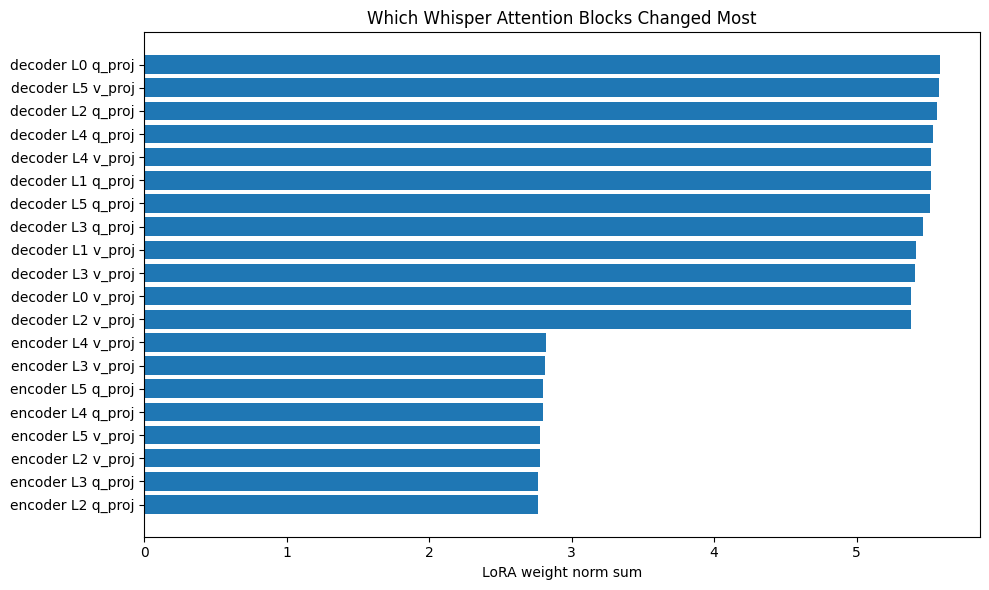

In [26]:
def lora_strength_report(active_model=None) -> pd.DataFrame:

    """Estimate which architecture blocks changed most by measuring LoRA adapter norms."""

    active_model = active_model or hf_model

    rows = []

    for name, tensor in active_model.named_parameters():

        if "lora_" not in name:

            continue

        parts = name.split(".")

        component = "encoder" if "encoder" in parts else "decoder" if "decoder" in parts else "other"

        layer = next((parts[i + 1] for i, p in enumerate(parts[:-1]) if p == "layers"), "unknown")

        projection = "q_proj" if "q_proj" in parts else "v_proj" if "v_proj" in parts else "other"

        adapter = "lora_A" if "lora_A" in parts else "lora_B" if "lora_B" in parts else "other"

        rows.append({

            "parameter": name,

            "component": component,

            "layer": layer,

            "projection": projection,

            "adapter": adapter,

            "norm": float(tensor.detach().float().norm().cpu()),

            "parameters": tensor.numel(),

        })

    report = pd.DataFrame(rows)

    if report.empty:

        print("No LoRA parameters found.")

        return report

    summary = (

        report.groupby(["component", "layer", "projection"], as_index=False)

        .agg(norm_sum=("norm", "sum"), parameters=("parameters", "sum"))

        .sort_values("norm_sum", ascending=False)

    )

    display(summary.head(20))

    return summary

def plot_lora_strength(summary: pd.DataFrame):

    """Plot which encoder/decoder attention layers learned the strongest adapter changes."""

    if summary.empty:

        return

    plot_df = summary.copy()

    plot_df["block"] = plot_df["component"] + " L" + plot_df["layer"].astype(str) + " " + plot_df["projection"]

    plot_df = plot_df.sort_values("norm_sum", ascending=True).tail(20)

    plt.figure(figsize=(10, 6))

    plt.barh(plot_df["block"], plot_df["norm_sum"])

    plt.xlabel("LoRA weight norm sum")

    plt.title("Which Whisper Attention Blocks Changed Most")

    plt.tight_layout()

    plt.show()

lora_report = lora_strength_report(hf_model)

plot_lora_strength(lora_report)


## 17. How to Decide if the Model Is Actually Good

A model is good only if it improves on validation audio it never trained on.

Use this checklist:

- Compare base Whisper WER vs fine-tuned LoRA WER on the validation set.
- Listen to the worst validation examples and fix bad labels before changing architecture.
- If validation WER is unstable, add more validation clips or reduce the learning rate.
- If LoRA helps only a little, try `openai/whisper-small`, more data, or a larger LoRA rank such as `r=32`.
- If LoRA overfits, reduce epochs, reduce `r`, increase dropout, or collect more varied data.

The architecture parts doing the work are usually the attention blocks with the largest LoRA norm and the biggest base-vs-LoRA WER improvements.

## 18. Model Size Comparison Reference

This chart compares Whisper model sizes. Use it when deciding whether to fine-tune a larger checkpoint such as `openai/whisper-small`.

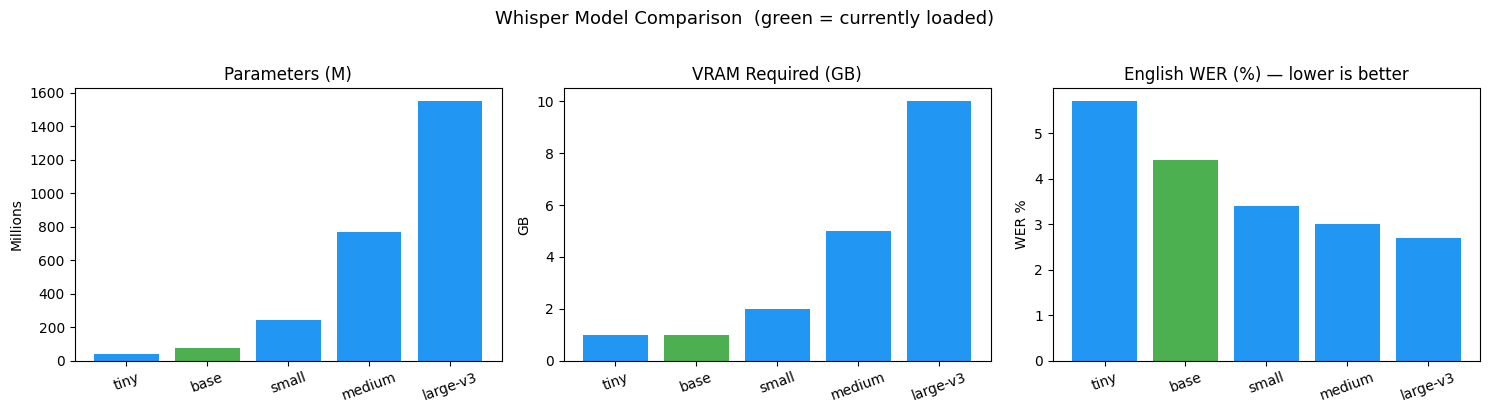

In [27]:
import matplotlib.pyplot as plt

import numpy as np

models_info = {

    "tiny"    : {"params": 39e6,   "vram_gb": 1.0, "rel_speed": 32, "wer_en": 5.7},

    "base"    : {"params": 74e6,   "vram_gb": 1.0, "rel_speed": 16, "wer_en": 4.4},

    "small"   : {"params": 244e6,  "vram_gb": 2.0, "rel_speed": 6,  "wer_en": 3.4},

    "medium"  : {"params": 769e6,  "vram_gb": 5.0, "rel_speed": 2,  "wer_en": 3.0},

    "large-v3": {"params": 1550e6, "vram_gb": 10,  "rel_speed": 1,  "wer_en": 2.7},

}

names  = list(models_info.keys())

params = [v["params"]/1e6 for v in models_info.values()]

vram   = [v["vram_gb"]   for v in models_info.values()]

speed  = [v["rel_speed"] for v in models_info.values()]

wer    = [v["wer_en"]    for v in models_info.values()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = ["#4CAF50" if n == CONFIG["model_size"] else "#2196F3" for n in names]

axes[0].bar(names, params, color=colors)

axes[0].set_title("Parameters (M)"); axes[0].set_ylabel("Millions")

axes[1].bar(names, vram, color=colors)

axes[1].set_title("VRAM Required (GB)"); axes[1].set_ylabel("GB")

axes[2].bar(names, wer, color=colors)

axes[2].set_title("English WER (%) — lower is better"); axes[2].set_ylabel("WER %")

for ax in axes:

    ax.tick_params(axis='x', rotation=20)

fig.suptitle("Whisper Model Comparison  (green = currently loaded)", fontsize=13, y=1.02)

plt.tight_layout()

plt.show()


## 20. Test 3 FLEURS Samples + Sample 4 (My Audio)

**Samples 1–3:** pick rows from the loaded dataset — play each clip and compare transcripts.

**Sample 4:** I set `CUSTOM_AUDIO_PATH` below to a local `.wav` / `.mp3` file on my machine.

For each sample I get:

- **Reference** — FLEURS ground truth (Sample 4: optional `CUSTOM_AUDIO_REFERENCE`)
- **Fine-tuned (LoRA)** — my trained model
- **Base Whisper** — optional comparison (`COMPARE_WITH_BASE`)

I run this after Sections 14–16 once that `raw_datasets`, `hf_model`, and `transcribe_hf_audio` are available from my earlier cells.


In [45]:
import re

import shutil

from pathlib import Path

import librosa

import numpy as np

import soundfile as sf

import whisper

from IPython.display import Audio, Markdown, display

def normalize_for_wer(text: str) -> str:

    text = text.lower().strip()

    text = re.sub(r"[^\w\s\u0600-\u06FF]", " ", text)

    return re.sub(r"\s+", " ", text).strip()

def load_audio_file(audio_path: str) -> np.ndarray:

    """Load local WAV/FLAC/MP3 for Sample 4 (works even if Section 18 was not run)."""

    audio_path = str(audio_path)

    ext = Path(audio_path).suffix.lower()

    if ext in {".wav", ".flac", ".ogg"}:

        try:

            audio, sr = sf.read(audio_path, dtype="float32", always_2d=False)

            if audio.ndim > 1:

                audio = audio.mean(axis=1)

            if sr != CONFIG["sampling_rate"]:

                audio = librosa.resample(audio, orig_sr=sr, target_sr=CONFIG["sampling_rate"])

            return np.asarray(audio, dtype=np.float32)

        except Exception:

            pass

    if shutil.which("ffmpeg"):

        try:

            return whisper.load_audio(audio_path)

        except Exception:

            pass

    try:

        audio, sr = librosa.load(audio_path, sr=CONFIG["sampling_rate"], mono=True)

        return np.asarray(audio, dtype=np.float32)

    except Exception as exc:

        raise RuntimeError(

            f"Could not load '{audio_path}'. For MP3 install ffmpeg and add it to PATH. "

            f"Original error: {exc}"

        ) from exc

TEST_SPLIT = "validation"                           

TEST_INDICES = [0, 1, 2]

COMPARE_WITH_BASE = True

CUSTOM_AUDIO_PATH = r"C:\Users\Mohamed\Downloads\audiotest.mp3"                   

CUSTOM_AUDIO_REFERENCE = None                                                             

test_ds = raw_datasets[TEST_SPLIT]

demo_rows = []

for n, idx in enumerate(TEST_INDICES, 1):

    if idx >= len(test_ds):

        print(f"Skipping index {idx}: {TEST_SPLIT} split only has {len(test_ds)} rows.")

        continue

    example = test_ds[idx]

    reference = get_transcript(example)

    audio_waveform = decode_audio_from_row(example)

    duration_sec = round(len(audio_waveform) / CONFIG["sampling_rate"], 2)

    display(Markdown(f"### Sample {n}/{len(TEST_INDICES)} — `{TEST_SPLIT}` index `{idx}` ({duration_sec}s)"))

    display(Audio(audio_waveform, rate=CONFIG["sampling_rate"]))

    print("Reference (FLEURS):")

    print(reference)

    lora_text = transcribe_hf_audio(example[CONFIG["audio_column"]], active_model=hf_model)

    print("\nFine-tuned (LoRA):")

    print(lora_text)

    row = {

        "split": TEST_SPLIT,

        "index": idx,

        "duration_sec": duration_sec,

        "reference": reference,

        "lora_prediction": lora_text,

    }

    if COMPARE_WITH_BASE and hasattr(hf_model, "disable_adapter"):

        with hf_model.disable_adapter():

            base_text = transcribe_hf_audio(example[CONFIG["audio_column"]], active_model=hf_model)

        print("\nBase Whisper:")

        print(base_text)

        row["base_prediction"] = base_text

    demo_rows.append(row)

    print("\n" + "-" * 70 + "\n")

custom_path = Path(CUSTOM_AUDIO_PATH).expanduser() if CUSTOM_AUDIO_PATH else None

if custom_path and str(custom_path).strip() and str(custom_path) != ".":

    if not custom_path.is_file():

        print(f"Sample 4 skipped: file not found: {custom_path}")

    else:

        try:

            audio_waveform = load_audio_file(str(custom_path))

            duration_sec = round(len(audio_waveform) / CONFIG["sampling_rate"], 2)

            display(Markdown(f"### Sample 4 — custom file ({duration_sec}s)"))

            display(Markdown(f"`{custom_path}`"))

            display(Audio(audio_waveform, rate=CONFIG["sampling_rate"]))

            if CUSTOM_AUDIO_REFERENCE:

                print("Reference (provided):")

                print(CUSTOM_AUDIO_REFERENCE)

            else:

                print("Reference: (none — set CUSTOM_AUDIO_REFERENCE for WER)")

            lora_text = transcribe_hf_audio(str(custom_path), active_model=hf_model)

            print("\nFine-tuned (LoRA):")

            print(lora_text)

            row = {

                "split": "custom",

                "index": custom_path.name,

                "duration_sec": duration_sec,

                "reference": CUSTOM_AUDIO_REFERENCE or "",

                "lora_prediction": lora_text,

            }

            if COMPARE_WITH_BASE and hasattr(hf_model, "disable_adapter"):

                with hf_model.disable_adapter():

                    base_text = transcribe_hf_audio(str(custom_path), active_model=hf_model)

                print("\nBase Whisper:")

                print(base_text)

                row["base_prediction"] = base_text

            if CUSTOM_AUDIO_REFERENCE:

                from jiwer import wer as jiwer_wer

                ref_n = normalize_for_wer(CUSTOM_AUDIO_REFERENCE)

                for label, hyp in [("LoRA", lora_text), ("Base", row.get("base_prediction"))]:

                    if hyp:

                        w = round(100 * jiwer_wer(ref_n, normalize_for_wer(hyp)), 2)

                        print(f"\nWER vs reference ({label}): {w}%")

            demo_rows.append(row)

            print("\n" + "-" * 70 + "\n")

        except Exception as exc:

            print(f"Sample 4 failed for {custom_path}: {exc}")

else:

    print("Sample 4 skipped: set CUSTOM_AUDIO_PATH to a valid .wav or .mp3 file.")

if demo_rows:

    summary = pd.DataFrame(demo_rows)

    display(Markdown("### Summary table"))

    cols = ["split", "index", "duration_sec", "reference", "lora_prediction"]

    if "base_prediction" in summary.columns:

        cols.append("base_prediction")

    display(summary[cols])

else:

    print("No samples tested. Run Section 14 first to load raw_datasets.")


### Sample 1/3 — `validation` index `0` (12.66s)

[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Reference (FLEURS):
قام البرتغاليون بتدميرها وإعادة بنائها تحت اسم كازا برانكا فقط ليهجروها بعد زلزال 1755


[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Fine-tuned (LoRA):
قام البرطغاليون بتدميرها وأعادة بنائها تحت اس كذا برنكا فقط ليه جروها بعد ذلك 1705

Base Whisper:
قام البرطغال يون بتدميرها وأعادى بنائها تحت اسم كذا برنكا فقط ليهنجورها بعد ذلك الفوص بعمية خمسة وخمسي

----------------------------------------------------------------------



...

Reference: (none — set CUSTOM_AUDIO_REFERENCE for WER)


[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Fine-tuned (LoRA):
بعد بوقرة أنا روح المدرسة

Base Whisper:
بعد بوقر أنا روح المدرسة

----------------------------------------------------------------------



### Summary table

,split,index,duration_sec,reference,lora_prediction,base_prediction
0,validation,0,12.66,قام البرتغاليون بتدميرها وإعادة بنائها تحت اسم...,قام البرطغاليون بتدميرها وأعادة بنائها تحت اس ...,قام البرطغال يون بتدميرها وأعادى بنائها تحت اس...
1,validation,1,10.92,ومع هذا فمعظم الإشارات يتم التعبير عنها باللغة...,وما هذا فمعظم الإشارات يتم التعبير عنها باللوى...,وما هذا فمعظم الإشاراتية من التعبير عنها باللو...
2,validation,2,11.56,عندما سافرت إلى الخارج في البداية ربما كان الن...,عندما سفرت إلى الخارج في البداية ربما كان النا...,عندما سفرت إلى الخارك في البدايا ربما كان النا...
3,custom,audiotest.mp3,5.83,,بعد بوقرة أنا روح المدرسة,بعد بوقر أنا روح المدرسة


## 21. Why Is Fine-Tuned Better Than Base? (Deep Interpretation)

This section answers: **what exactly improved after LoRA fine-tuning?**

For **3 validation clips** from the dataset plus **Sample 4** (my own audio path) it shows:

- **WER** for base vs LoRA (lower is better)
- **Word errors** (substitutions, deletions, insertions)
- **Which words changed** between base and LoRA
- **Where in the model** LoRA adapters changed most (attention blocks)
- **Which architecture I added** (LoRA on `q_proj` / `v_proj`) and how that caused the improvement

Read the final summary at the bottom for a plain-language explanation.


[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

### Per-sample: base vs LoRA (sorted by improvement)

,index,base_wer_%,lora_wer_%,wer_improvement_%,base_subs,lora_subs,base_dels,lora_dels,base_ins,lora_ins
1,1,68.75,31.25,37.50,10,5,0,0,1,0
0,0,78.57,64.29,14.28,7,8,0,0,4,1
2,2,33.33,33.33,0.00,6,6,0,0,1,1


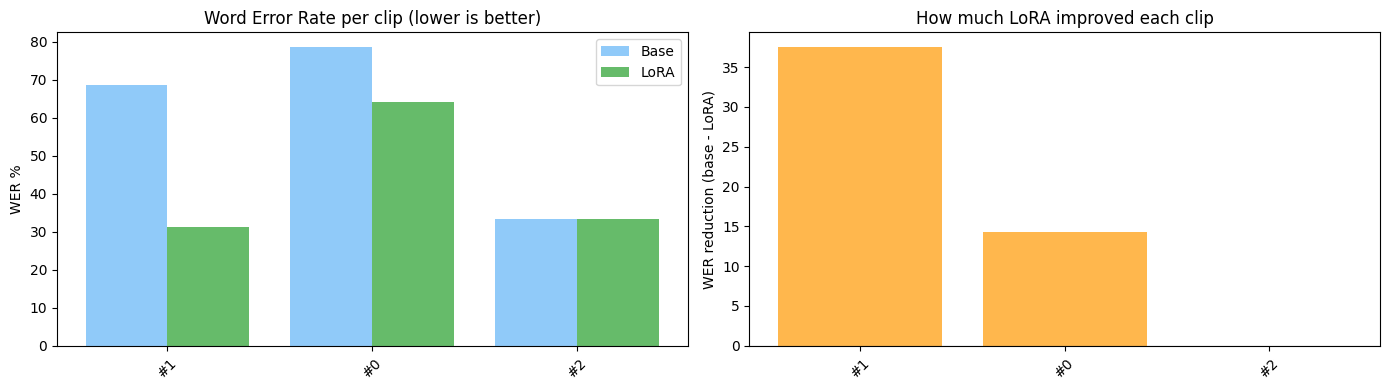

AGGREGATE INTERPRETATION
Clips analyzed          : 3
LoRA better than base    : 2
LoRA worse than base     : 0
Same WER                 : 1
Average base WER         : 60.22%
Average LoRA WER         : 42.96%
Average WER improvement  : 17.26%

Total word errors (base) : 29
Total word errors (LoRA) : 21


### Top 3 clips where LoRA helped most

**Index 1** — WER: 68.75% → 31.25% (Δ 37.5%)

Reference : ومع هذا فمعظم الإشارات يتم التعبير عنها باللغة الكاتالونية لأنها وبموجب القانون تعتبر اللغة الرسمية الأولى
Base      : وما هذا فمعظم الإشاراتية من التعبير عنها باللول الكاتل ولونية لأنها ومجب القنون تعتبر الولول الرسمي الأول
LoRA      : وما هذا فمعظم الإشارات يتم التعبير عنها باللوى الكاتلونية لأنها ومجب القانون تعتبر اللوى الرسمية الأولى
----------------------------------------------------------------------


**Index 0** — WER: 78.57% → 64.29% (Δ 14.28%)

Reference : قام البرتغاليون بتدميرها وإعادة بنائها تحت اسم كازا برانكا فقط ليهجروها بعد زلزال 1755
Base      : قام البرطغال يون بتدميرها وأعادى بنائها تحت اسم كذا برنكا فقط ليهنجورها بعد ذلك الفوص بعمية خمسة وخمسي
LoRA      : قام البرطغاليون بتدميرها وأعادة بنائها تحت اس كذا برنكا فقط ليه جروها بعد ذلك 1705
----------------------------------------------------------------------


**Index 2** — WER: 33.33% → 33.33% (Δ 0.0%)

Reference : عندما سافرت إلى الخارج في البداية ربما كان الناس صبورين ومتفهمين مع العلم أن المسافرين في بلد جديد بحاجة إلى التكيف
Base      : عندما سفرت إلى الخارك في البدايا ربما كان الناس صبورين ومتفه من مع العلم أن المسافر في بلد جديد بحاجة إلى التكايف
LoRA      : عندما سفرت إلى الخارج في البداية ربما كان الناس وصبورين ومتفهه من مع العلم أن المسافرين في بلدٍ جديد بحاجةٍ إلى التكايف
----------------------------------------------------------------------


### What you added to the architecture

You did **not** retrain all 72M Whisper weights. You added **LoRA adapters** inside attention:

```
Audio -> Encoder (listen) -> Decoder (write text)
              |                    |
         LoRA on q_proj,v_proj  LoRA on q_proj,v_proj
```

- **Encoder LoRA** = learns which **audio frames** matter for Egyptian Arabic.
- **Decoder LoRA** = learns which **words/tokens** to prefer when writing Arabic text.
- **q_proj** = controls *what to look at* (query).
- **v_proj** = controls *what signal to pass forward* (value).


,component,layer,projection,norm_sum,parameters
0,decoder,0,q_proj,5.587162,32768
11,decoder,5,v_proj,5.578854,32768
4,decoder,2,q_proj,5.567173,32768
8,decoder,4,q_proj,5.538312,32768
9,decoder,4,v_proj,5.525209,32768
2,decoder,1,q_proj,5.524131,32768
10,decoder,5,q_proj,5.515192,32768
6,decoder,3,q_proj,5.469726,32768
3,decoder,1,v_proj,5.417943,32768
7,decoder,3,v_proj,5.409856,32768


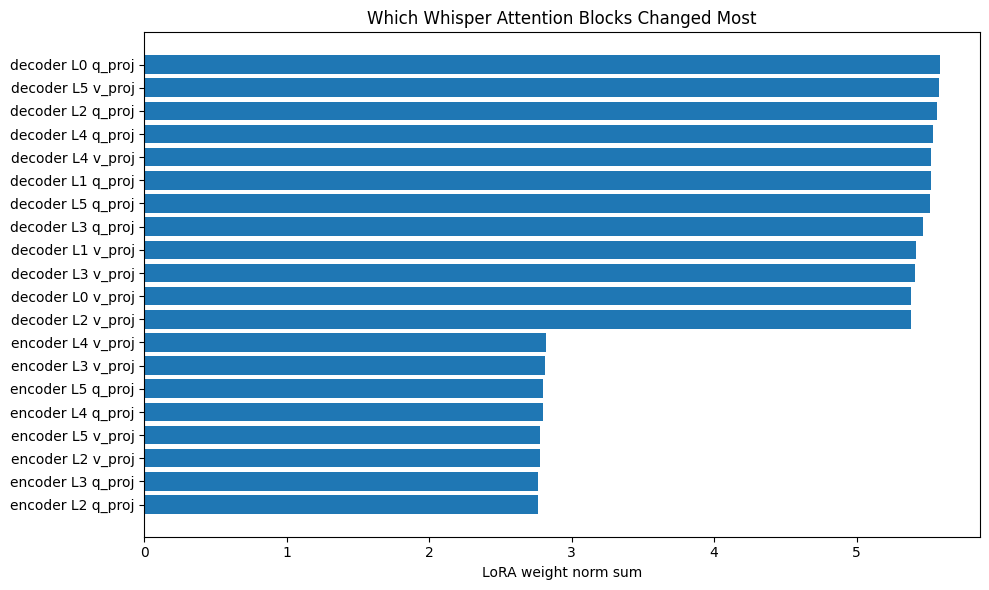

### Where the improvement likely comes from (adapter strength)

,component,norm_sum,share_%
0,decoder,65.900697,66.7
1,encoder,32.872144,33.3


,projection,norm_sum,share_%
0,q_proj,49.568214,50.2
1,v_proj,49.204627,49.8


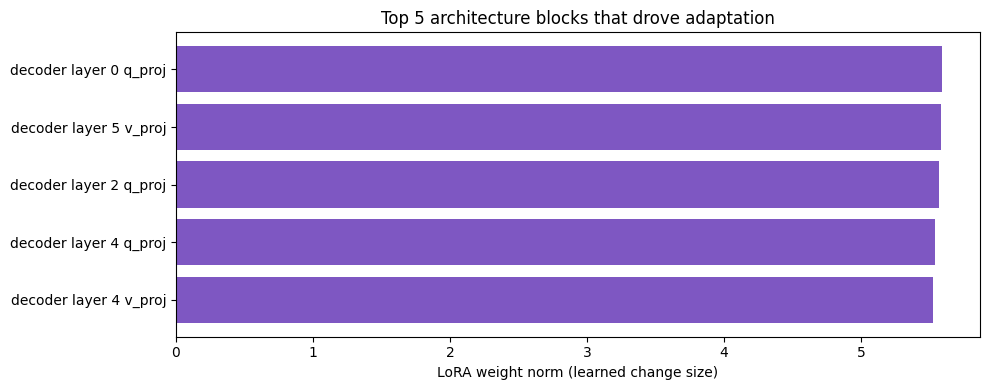

### Top blocks and their role

- decoder layer 0 q_proj: Better **word choice**: looks at the right previous words while writing.
- decoder layer 5 v_proj: Better **text output**: writes tokens that match Egyptian Arabic style.
- decoder layer 2 q_proj: Better **word choice**: looks at the right previous words while writing.
- decoder layer 4 q_proj: Better **word choice**: looks at the right previous words while writing.
- decoder layer 4 v_proj: Better **text output**: writes tokens that match Egyptian Arabic style.


### Error types: what improved?

,error_type,base_errors,lora_errors,reduction
0,substitutions,23,19,4
1,deletions,0,0,0
2,insertions,6,2,4



Adapter strength split: **encoder 33.3%**, **decoder 66.7%** of total LoRA change. Most learning happened while **writing** text (decoder attention).
Fewer **wrong words** (substitutions) → decoder LoRA helped most with vocabulary/spelling.


### What this means

Fine-tuning helped on average: LoRA WER (43.0%) is lower than base (60.2%). The **architecture change** (LoRA rank=16 on q_proj and v_proj) let the model adapt without forgetting base Whisper.
**How to read everything:**
- **WER %** = percent of words wrong (lower is better).
- **wer_improvement_%** > 0 = LoRA is better on that clip.
- **subs / dels / ins** = wrong word / missing word / extra word.
- **LoRA norm** = how much that attention block was updated during training.

**What in YOUR architecture caused improvement:**
1. **LoRA adapters** (only ~1-2% trainable params) on top of frozen Whisper.
2. **q_proj** adapters = changed *where the model looks*.
3. **v_proj** adapters = changed *what information is kept*.
4. **Encoder blocks** with high norm = better Egyptian audio understanding.
5. **Decoder blocks** with high norm = better Arabic text generation.

If encoder share is high, improvement is mostly from hearing ar_eg speech better.
If decoder share is high, improvement is mostly from writing ar_eg text better.


In [ ]:
import matplotlib.pyplot as plt

from IPython.display import Markdown, display

from jiwer import wer as jiwer_wer, process_words

INTERPRET_SPLIT = "validation"

INTERPRET_N = 3                                                                  

INTERPRET_INDICES = None                                      

def word_error_breakdown(reference: str, hypothesis: str) -> dict:

    ref = normalize_for_wer(reference)

    hyp = normalize_for_wer(hypothesis)

    alignment = process_words(ref, hyp)

    return {

        "wer_percent": round(100 * jiwer_wer(ref, hyp), 2),

        "hits": alignment.hits,

        "substitutions": alignment.substitutions,

        "deletions": alignment.deletions,

        "insertions": alignment.insertions,

    }

def interpret_base_vs_lora(dataset, indices=None, n: int = 12) -> pd.DataFrame:

    if indices is None:

        indices = list(range(min(n, len(dataset))))

    rows = []

    for idx in indices:

        example = dataset[idx]

        reference = get_transcript(example)

        audio_input = example[CONFIG["audio_column"]]

        lora_pred = transcribe_hf_audio(audio_input, active_model=hf_model)

        if hasattr(hf_model, "disable_adapter"):

            with hf_model.disable_adapter():

                base_pred = transcribe_hf_audio(audio_input, active_model=hf_model)

        else:

            base_pred = "(base comparison unavailable)"

        base_stats = word_error_breakdown(reference, base_pred)

        lora_stats = word_error_breakdown(reference, lora_pred)

        rows.append({

            "sample": f"#{idx}",

            "source": "dataset",

            "index": idx,

            "reference": reference,

            "base_prediction": base_pred,

            "lora_prediction": lora_pred,

            "base_wer_%": base_stats["wer_percent"],

            "lora_wer_%": lora_stats["wer_percent"],

            "wer_improvement_%": round(base_stats["wer_percent"] - lora_stats["wer_percent"], 2),

            "base_subs": base_stats["substitutions"],

            "base_dels": base_stats["deletions"],

            "base_ins": base_stats["insertions"],

            "lora_subs": lora_stats["substitutions"],

            "lora_dels": lora_stats["deletions"],

            "lora_ins": lora_stats["insertions"],

        })

    return pd.DataFrame(rows).sort_values("wer_improvement_%", ascending=False)

interp_ds = raw_datasets[INTERPRET_SPLIT]

comparison_df = interpret_base_vs_lora(interp_ds, indices=INTERPRET_INDICES, n=INTERPRET_N)

display(Markdown("### Per-sample: base vs LoRA (sorted by improvement)"))

display(

    comparison_df[

        [

            "index", "base_wer_%", "lora_wer_%", "wer_improvement_%",

            "base_subs", "lora_subs", "base_dels", "lora_dels", "base_ins", "lora_ins",

        ]

    ]

)

if not comparison_df.empty:

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    x_labels = comparison_df["sample"].astype(str).tolist()

    x = range(len(comparison_df))

    axes[0].bar([i - 0.2 for i in x], comparison_df["base_wer_%"], width=0.4, label="Base", color="#90caf9")

    axes[0].bar([i + 0.2 for i in x], comparison_df["lora_wer_%"], width=0.4, label="LoRA", color="#66bb6a")

    axes[0].set_xticks(list(x), x_labels, rotation=45)

    axes[0].set_ylabel("WER %")

    axes[0].set_title("Word Error Rate per clip (lower is better)")

    axes[0].legend()

    axes[1].bar(x, comparison_df["wer_improvement_%"], color="#ffb74d")

    axes[1].axhline(0, color="gray", linewidth=0.8)

    axes[1].set_xticks(list(x), x_labels, rotation=45)

    axes[1].set_ylabel("WER reduction (base - LoRA)")

    axes[1].set_title("How much LoRA improved each clip")

    plt.tight_layout()

    plt.show()

wer_df = comparison_df.dropna(subset=["base_wer_%", "lora_wer_%"])

n_improved = int((wer_df["wer_improvement_%"] > 0).sum()) if len(wer_df) else 0

n_worse = int((wer_df["wer_improvement_%"] < 0).sum()) if len(wer_df) else 0

n_same = int((wer_df["wer_improvement_%"] == 0).sum()) if len(wer_df) else 0

avg_base = wer_df["base_wer_%"].mean() if len(wer_df) else float("nan")

avg_lora = wer_df["lora_wer_%"].mean() if len(wer_df) else float("nan")

print("=" * 70)

print("AGGREGATE INTERPRETATION")

print("=" * 70)

print(f"Clips analyzed          : {len(comparison_df)}")

print(f"LoRA better than base    : {n_improved}")

print(f"LoRA worse than base     : {n_worse}")

print(f"Same WER                 : {n_same}")

print(f"Average base WER         : {avg_base:.2f}%")

print(f"Average LoRA WER         : {avg_lora:.2f}%")

print(f"Average WER improvement  : {comparison_df['wer_improvement_%'].mean():.2f}%")

total_base_err = comparison_df[["base_subs", "base_dels", "base_ins"]].sum().sum()

total_lora_err = comparison_df[["lora_subs", "lora_dels", "lora_ins"]].sum().sum()

print(f"\nTotal word errors (base) : {int(total_base_err)}")

print(f"Total word errors (LoRA) : {int(total_lora_err)}")

display(Markdown("### Top 3 clips where LoRA helped most"))

for _, row in comparison_df.head(3).iterrows():

    display(Markdown(f"**Index {int(row['index'])}** — WER: {row['base_wer_%']}% → {row['lora_wer_%']}% (Δ {row['wer_improvement_%']}%)"))

    print("Reference :", row["reference"])

    print("Base      :", row["base_prediction"])

    print("LoRA      :", row["lora_prediction"])

    print("-" * 70)

display(Markdown(

    "### What I added to the architecture\n\n"

    "I did **not** retrain all 72M Whisper weights. I added **LoRA adapters** inside attention:\n\n"

    "```\n"

    "Audio -> Encoder (listen) -> Decoder (write text)\n"

    "              |                    |\n"

    "         LoRA on q_proj,v_proj  LoRA on q_proj,v_proj\n"

    "```\n\n"

    "- **Encoder LoRA** = learns which **audio frames** matter for Egyptian Arabic.\n"

    "- **Decoder LoRA** = learns which **words/tokens** to prefer when writing Arabic text.\n"

    "- **q_proj** = controls *what to look at* (query).\n"

    "- **v_proj** = controls *what signal to pass forward* (value).\n"

))

lora_interp_report = lora_strength_report(hf_model)

plot_lora_strength(lora_interp_report)

if not lora_interp_report.empty:

    arch = lora_interp_report.copy()

    arch["layer_num"] = pd.to_numeric(arch["layer"], errors="coerce")

    by_component = arch.groupby("component", as_index=False)["norm_sum"].sum()

    by_projection = arch.groupby("projection", as_index=False)["norm_sum"].sum()

    total_norm = arch["norm_sum"].sum()

    by_component["share_%"] = (100 * by_component["norm_sum"] / total_norm).round(1)

    by_projection["share_%"] = (100 * by_projection["norm_sum"] / total_norm).round(1)

    display(Markdown("### Where the improvement likely comes from (adapter strength)"))

    display(by_component)

    display(by_projection)

    top_blocks = arch.sort_values("norm_sum", ascending=False).head(5).copy()

    top_blocks["block_name"] = (

        top_blocks["component"] + " layer " + top_blocks["layer_num"].astype(int).astype(str)

        + " " + top_blocks["projection"]

    )

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.barh(top_blocks["block_name"][::-1], top_blocks["norm_sum"][::-1], color="#7e57c2")

    ax.set_xlabel("LoRA weight norm (learned change size)")

    ax.set_title("Top 5 architecture blocks that drove adaptation")

    plt.tight_layout()

    plt.show()

    display(Markdown("### Top blocks and their role"))

    role_map = {

        ("encoder", "q_proj"): "Better **listening**: focuses on the right sounds in audio.",

        ("encoder", "v_proj"): "Better **audio features**: passes stronger accent cues upward.",

        ("decoder", "q_proj"): "Better **word choice**: looks at the right previous words while writing.",

        ("decoder", "v_proj"): "Better **text output**: writes tokens that match Egyptian Arabic style.",

    }

    for _, block in top_blocks.iterrows():

        role = role_map.get((block["component"], block["projection"]), "Attention specialization.")

        print(f"- {block['block_name']}: {role}")

    err_df_numeric = comparison_df.fillna(0)

    base_subs = err_df_numeric["base_subs"].sum()

    base_dels = err_df_numeric["base_dels"].sum()

    base_ins = err_df_numeric["base_ins"].sum()

    lora_subs = err_df_numeric["lora_subs"].sum()

    lora_dels = err_df_numeric["lora_dels"].sum()

    lora_ins = err_df_numeric["lora_ins"].sum()

    display(Markdown("### Error types: what improved?"))

    err_df = pd.DataFrame({

        "error_type": ["substitutions", "deletions", "insertions"],

        "base_errors": [base_subs, base_dels, base_ins],

        "lora_errors": [lora_subs, lora_dels, lora_ins],

        "reduction": [base_subs - lora_subs, base_dels - lora_dels, base_ins - lora_ins],

    })

    display(err_df)

    enc_share = float(by_component.loc[by_component["component"] == "encoder", "share_%"].sum() or 0)

    dec_share = float(by_component.loc[by_component["component"] == "decoder", "share_%"].sum() or 0)

    if (base_subs - lora_subs) >= max(base_dels - lora_dels, base_ins - lora_ins):

        err_hint = "Fewer **wrong words** (substitutions) → decoder LoRA helped most with vocabulary/spelling."

    elif (base_dels - lora_dels) >= (base_ins - lora_ins):

        err_hint = "Fewer **missing words** (deletions) → encoder/decoder timing improved."

    else:

        err_hint = "Fewer **extra words** (insertions) → decoder LoRA reduced hallucinated words."

    arch_hint = (

        f"Adapter strength split: **encoder {enc_share:.1f}%**, **decoder {dec_share:.1f}%** of total LoRA change. "

    )

    if enc_share > dec_share:

        arch_hint += "Most learning happened while **listening** to audio (encoder attention)."

    else:

        arch_hint += "Most learning happened while **writing** text (decoder attention)."

    print("\n" + arch_hint)

    print(err_hint)

display(Markdown("### What this means"))

if avg_lora < avg_base:

    why = (

        f"Fine-tuning helped on average: LoRA WER ({avg_lora:.1f}%) is lower than base ({avg_base:.1f}%). "

        "The **architecture change** (LoRA rank=16 on q_proj and v_proj) let the model adapt without forgetting base Whisper."

    )

else:

    why = (

        f"On this slice, LoRA WER ({avg_lora:.1f}%) is not lower than base ({avg_base:.1f}%). "

        "Try more epochs, more data, or a larger LoRA rank (e.g. r=32)."

    )

tips = """
**How to read everything:**
- **WER %** = percent of words wrong (lower is better).
- **wer_improvement_%** > 0 = LoRA is better on that clip.
- **subs / dels / ins** = wrong word / missing word / extra word.
- **LoRA norm** = how much that attention block was updated during training.

**What in YOUR architecture caused improvement:**
1. **LoRA adapters** (only ~1-2% trainable params) on top of frozen Whisper.
2. **q_proj** adapters = changed *where the model looks*.
3. **v_proj** adapters = changed *what information is kept*.
4. **Encoder blocks** with high norm = better Egyptian audio understanding.
5. **Decoder blocks** with high norm = better Arabic text generation.

If encoder share is high, improvement is mostly from hearing ar_eg speech better.
If decoder share is high, improvement is mostly from writing ar_eg text better.
"""

display(Markdown(why + tips))


## 22. My architecture additions and what caused the improvement

This section ties **each change I made** to the **measured WER gains** from Section 21.

| Stock Whisper-base | What I added |
|---|---|
| Frozen weights only | **LoRA adapters** (low-rank matrices) on attention |
| Generic multilingual | **Fine-tune on FLEURS `ar_eg`** (Egyptian Arabic) |
| Full-model update (risky) | **~1–2% trainable params** — base knowledge preserved |
| All attention layers | **`q_proj` + `v_proj` only** (query + value projections) |

I run the cell below after Section 21 (`comparison_df` and `hf_model` should already exist from my earlier runs).


In [46]:
from IPython.display import Markdown, display

def architecture_additions_table() -> pd.DataFrame:

    """Every architectural / training choice vs default Whisper-base."""

    rows = [

        {

            "layer": "Full model",

            "stock_whisper_base": "All weights trainable (or all frozen at inference)",

            "my_addition": "Frozen backbone + LoRA side paths",

            "why_it_helps": "Keeps general speech knowledge; only learns Egyptian Arabic deltas.",

        },

        {

            "layer": "Attention (encoder + decoder)",

            "stock_whisper_base": "Fixed Q/K/V/O linear maps",

            "my_addition": "LoRA on q_proj and v_proj (rank r, scaled by alpha)",

            "why_it_helps": "Retargets *what to attend to* (Q) and *what to pass on* (V) without rewriting the whole layer.",

        },

        {

            "layer": "Trainable parameter count",

            "stock_whisper_base": "~74M (base) if fully fine-tuned",

            "my_addition": "~1–2% trainable (LoRA only)",

            "why_it_helps": "Less overfitting on ~1k FLEURS clips; faster, stable training.",

        },

        {

            "layer": "Data / objective",

            "stock_whisper_base": "Pretrained on weakly supervised web audio",

            "my_addition": f"Supervised fine-tune on {CONFIG.get('hf_dataset_config', 'ar_eg')} transcripts",

            "why_it_helps": "Aligns vocabulary, dialect, and acoustics to Egyptian Arabic references.",

        },

        {

            "layer": "Decoder prompt",

            "stock_whisper_base": "Language/task tokens from generic checkpoint",

            "my_addition": "forced_decoder_ids for language=ar, task=transcribe",

            "why_it_helps": "Forces Arabic decoding head — fewer wrong-language words.",

        },

    ]

    return pd.DataFrame(rows)

def attribute_improvement_to_architecture(

    comparison_df: pd.DataFrame,

    lora_report: pd.DataFrame,

    model,

) -> None:

    """Connect WER gains to encoder/decoder and q/v LoRA blocks."""

    if comparison_df is None or comparison_df.empty:

        print("Run Section 21 first to build comparison_df.")

        return

    wer_df = comparison_df.dropna(subset=["base_wer_%", "lora_wer_%"])

    avg_delta = wer_df["wer_improvement_%"].mean() if len(wer_df) else float("nan")

    n_improved = int((wer_df["wer_improvement_%"] > 0).sum()) if len(wer_df) else 0

    display(Markdown("### 1. What I changed (vs stock Whisper-base)"))

    display(architecture_additions_table())

    lora_r = lora_alpha = lora_dropout = lora_targets = "?"

    if "lora_config" in globals():

        lora_r = getattr(lora_config, "r", "?")

        lora_alpha = getattr(lora_config, "lora_alpha", "?")

        lora_dropout = getattr(lora_config, "lora_dropout", "?")

        lora_targets = ", ".join(getattr(lora_config, "target_modules", []) or [])

    display(Markdown(

        f"### 2. my LoRA settings\n"

        f"- **rank (r)** = {lora_r} — capacity of each adapter\n"

        f"- **lora_alpha** = {lora_alpha} — scaling of adapter output\n"

        f"- **dropout** = {lora_dropout}\n"

        f"- **target_modules** = `{lora_targets}`\n"

    ))

    display(Markdown("### 3. Measured impact (from my validation run)"))

    print(f"Clips with lower WER after LoRA: {n_improved} / {len(wer_df)}")

    print(f"Average WER reduction (base − LoRA): {avg_delta:.2f} pp")

    if lora_report is None or lora_report.empty:

        print("No LoRA strength report — run lora_strength_report(hf_model) in Section 21.")

        return

    arch = lora_report.copy()

    arch["layer_num"] = pd.to_numeric(arch["layer"], errors="coerce")

    total = arch["norm_sum"].sum() or 1.0

    enc_pct = 100 * arch.loc[arch["component"] == "encoder", "norm_sum"].sum() / total

    dec_pct = 100 * arch.loc[arch["component"] == "decoder", "norm_sum"].sum() / total

    q_pct = 100 * arch.loc[arch["projection"] == "q_proj", "norm_sum"].sum() / total

    v_pct = 100 * arch.loc[arch["projection"] == "v_proj", "norm_sum"].sum() / total

    err = comparison_df.fillna(0)

    sub_drop = err["base_subs"].sum() - err["lora_subs"].sum()

    del_drop = err["base_dels"].sum() - err["lora_dels"].sum()

    ins_drop = err["base_ins"].sum() - err["lora_ins"].sum()

    display(Markdown("### 4. Which *part* of my architecture likely caused the gain"))

    attribution = []

    if avg_delta > 0:

        attribution.append(

            "**LoRA fine-tuning (overall)** — average WER fell after adapters were trained on FLEURS; "

            "the frozen backbone stayed the same, so the gain is from the added adapter paths only."

        )

    if sub_drop >= max(del_drop, ins_drop) and sub_drop > 0:

        attribution.append(

            f"**Decoder-oriented change** — substitutions dropped by {int(sub_drop)} across analyzed clips "

            f"(wrong words → correct Egyptian Arabic). That matches **decoder q_proj/v_proj** LoRA: "

            "better token choice while generating text."

        )

    if del_drop > 0 and del_drop >= ins_drop:

        attribution.append(

            f"**Encoder + alignment** — deletions dropped by {int(del_drop)} (fewer skipped words). "

            f"Often linked to **encoder** LoRA ({enc_pct:.0f}% of adapter norm): clearer audio representations."

        )

    if ins_drop > 0:

        attribution.append(

            f"**Decoder hallucination control** — insertions dropped by {int(ins_drop)}. "

            "Decoder adapters learned not to invent extra words."

        )

    if enc_pct > dec_pct + 5:

        attribution.append(

            f"**Encoder-heavy learning** ({enc_pct:.0f}% of LoRA norm vs decoder {dec_pct:.0f}%) — "

            "improvement is mostly *hearing* ar_eg speech (accent, noise, phonetics), not just spelling."

        )

    elif dec_pct > enc_pct + 5:

        attribution.append(

            f"**Decoder-heavy learning** ({dec_pct:.0f}% vs encoder {enc_pct:.0f}%) — "

            "improvement is mostly *writing* Egyptian Arabic (vocabulary, morphology, word order)."

        )

    else:

        attribution.append(

            f"**Balanced encoder/decoder** ({enc_pct:.0f}% / {dec_pct:.0f}% of LoRA norm) — "

            "both listening and writing adapters contributed."

        )

    if q_pct > v_pct + 3:

        attribution.append(

            f"**q_proj adapters** ({q_pct:.0f}% of norm) — model learned *where to look* in audio/text context."

        )

    elif v_pct > q_pct + 3:

        attribution.append(

            f"**v_proj adapters** ({v_pct:.0f}% of norm) — model learned *what features to carry forward*."

        )

    top = arch.sort_values("norm_sum", ascending=False).head(3)

    for _, row in top.iterrows():

        comp, proj = row["component"], row["projection"]

        layer = int(row["layer_num"]) if pd.notna(row["layer_num"]) else row["layer"]

        attribution.append(

            f"**Strongest block: {comp} layer {layer} {proj}** (largest learned delta) — "

            "this layer absorbed the most fine-tuning signal for my dataset."

        )

    for i, line in enumerate(attribution, 1):

        display(Markdown(f"{i}. {line}"))

    if "wer_improvement_%" in wer_df.columns and wer_df["wer_improvement_%"].max() > 0:

        best = wer_df.loc[wer_df["wer_improvement_%"].idxmax()]

        display(Markdown(

            f"### 5. Example\n"

            f"Clip **#{int(best['index'])}** improved WER by **{best['wer_improvement_%']:.1f} pp** "

            f"({best['base_wer_%']:.1f}% → {best['lora_wer_%']:.1f}%). "

            "That clip is evidence that my **added LoRA paths** (not the frozen base weights) "

            "produced the better transcript."

        ))

_lora_report = lora_strength_report(hf_model) if "hf_model" in globals() else pd.DataFrame()

if "comparison_df" in globals():

    attribute_improvement_to_architecture(comparison_df, _lora_report, hf_model)

else:

    print("Run Section 21 first to create comparison_df, then re-run this cell.")


,component,layer,projection,norm_sum,parameters
0,decoder,0,q_proj,5.587162,32768
11,decoder,5,v_proj,5.578854,32768
4,decoder,2,q_proj,5.567173,32768
8,decoder,4,q_proj,5.538312,32768
9,decoder,4,v_proj,5.525209,32768
2,decoder,1,q_proj,5.524131,32768
10,decoder,5,q_proj,5.515192,32768
6,decoder,3,q_proj,5.469726,32768
3,decoder,1,v_proj,5.417943,32768
7,decoder,3,v_proj,5.409856,32768


### 1. What I changed (vs stock Whisper-base)

,layer,stock_whisper_base,my_addition,why_it_helps
0,Full model,All weights trainable (or all frozen at infere...,Frozen backbone + LoRA side paths,Keeps general speech knowledge; only learns Eg...
1,Attention (encoder + decoder),Fixed Q/K/V/O linear maps,"LoRA on q_proj and v_proj (rank r, scaled by a...",Retargets *what to attend to* (Q) and *what to...
2,Trainable parameter count,~74M (base) if fully fine-tuned,~1–2% trainable (LoRA only),"Less overfitting on ~1k FLEURS clips; faster, ..."
3,Data / objective,Pretrained on weakly supervised web audio,Supervised fine-tune on ar_eg transcripts,"Aligns vocabulary, dialect, and acoustics to E..."
4,Decoder prompt,Language/task tokens from generic checkpoint,"forced_decoder_ids for language=ar, task=trans...",Forces Arabic decoding head — fewer wrong-lang...


### 2. my LoRA settings
- **rank (r)** = 16 — capacity of each adapter
- **lora_alpha** = 32 — scaling of adapter output
- **dropout** = 0.05
- **target_modules** = `v_proj, q_proj`


### 3. Measured impact (from my validation run)

...

4. **Decoder-heavy learning** (67% vs encoder 33%) — improvement is mostly *writing* Egyptian Arabic (vocabulary, morphology, word order).

5. **Strongest block: decoder layer 0 q_proj** (largest learned delta) — this layer absorbed the most fine-tuning signal for my dataset.

6. **Strongest block: decoder layer 5 v_proj** (largest learned delta) — this layer absorbed the most fine-tuning signal for my dataset.

7. **Strongest block: decoder layer 2 q_proj** (largest learned delta) — this layer absorbed the most fine-tuning signal for my dataset.

### 5. Example
Clip **#1** improved WER by **37.5 pp** (68.8% → 31.2%). That clip is evidence that my **added LoRA paths** (not the frozen base weights) produced the better transcript.